# 02 - EDA and Data Cleaning
Explores the dataset, checks data quality, and produces summary statistics.
Run 01_data_generation.ipynb first.

In [1]:
# Cell 1 - Imports and DB Connection
import sqlite3
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

BASE_DIR = Path('..').resolve()
DB_PATH  = BASE_DIR / 'data' / 'raw' / 'ecommerce.db'

assert DB_PATH.exists(), 'DB not found - run notebook 01 first'
conn = sqlite3.connect(DB_PATH)
print('Connected to:', DB_PATH)

Connected to: C:\Users\diyag\Desktop\projects\ecommerce\ecommerce-funnel-analysis\data\raw\ecommerce.db


In [2]:
# Cell 2 - Load All Tables
df_users       = pd.read_sql('SELECT * FROM users',       conn)
df_products    = pd.read_sql('SELECT * FROM products',    conn)
df_sessions    = pd.read_sql('SELECT * FROM sessions',    conn)
df_events      = pd.read_sql('SELECT * FROM events',      conn)
df_orders      = pd.read_sql('SELECT * FROM orders',      conn)
df_order_items = pd.read_sql('SELECT * FROM order_items', conn)

print('Table Shapes')
for name, df in [('users', df_users), ('products', df_products),
                 ('sessions', df_sessions), ('events', df_events),
                 ('orders', df_orders), ('order_items', df_order_items)]:
    print(f'  {name:<15} {df.shape[0]:>10,} rows  x  {df.shape[1]} cols')

Table Shapes
  users                5,000 rows  x  7 cols
  products               120 rows  x  8 cols
  sessions            34,509 rows  x  7 cols
  events              79,851 rows  x  7 cols
  orders               3,548 rows  x  8 cols
  order_items          4,425 rows  x  5 cols


In [3]:
# Cell 3 - Null and Duplicate Check
tables = {
    'users': df_users, 'products': df_products,
    'sessions': df_sessions, 'events': df_events,
    'orders': df_orders, 'order_items': df_order_items
}

print('Null Counts')
for name, df in tables.items():
    nulls = df.isnull().sum()
    has_nulls = nulls[nulls > 0]
    if len(has_nulls):
        for col, n in has_nulls.items():
            print(f'  {name}.{col:<22} {n:,} nulls ({n/len(df)*100:.1f}%)')
    else:
        print(f'  {name:<15} no nulls')

print()
print('Duplicate PK Check')
pk_map = {
    'users': 'user_id', 'products': 'product_id',
    'sessions': 'session_id', 'events': 'event_id',
    'orders': 'order_id', 'order_items': 'item_id'
}
for name, df in tables.items():
    pk   = pk_map[name]
    dups = df[pk].duplicated().sum()
    print(f'  {name:<15} {dups} duplicate {pk}s')

Null Counts
  users           no nulls
  products        no nulls
  sessions        no nulls
  events.product_id             43,193 nulls (54.1%)
  orders          no nulls
  order_items     no nulls

Duplicate PK Check
  users           0 duplicate user_ids
  products        0 duplicate product_ids
  sessions        0 duplicate session_ids
  events          0 duplicate event_ids
  orders          0 duplicate order_ids
  order_items     0 duplicate item_ids


In [4]:
# Cell 4 - Parse Dates
df_sessions['session_date'] = pd.to_datetime(df_sessions['session_date'])
df_events['timestamp']      = pd.to_datetime(df_events['timestamp'])
df_orders['order_date']     = pd.to_datetime(df_orders['order_date'])
df_users['signup_date']     = pd.to_datetime(df_users['signup_date'])

completed = df_orders[df_orders['status'] == 'completed'].copy()

print('Date Ranges')
print('  Sessions:', df_sessions['session_date'].min().date(), 'to', df_sessions['session_date'].max().date())
print('  Orders  :', df_orders['order_date'].min().date(), 'to', df_orders['order_date'].max().date())
print()
print('Order Status Split')
print(df_orders['status'].value_counts(normalize=True).mul(100).round(1).to_string())

Date Ranges
  Sessions: 2024-01-01 to 2024-06-30
  Orders  : 2024-01-01 to 2024-06-30

Order Status Split
status
completed    88.5
returned      6.3
cancelled     5.2


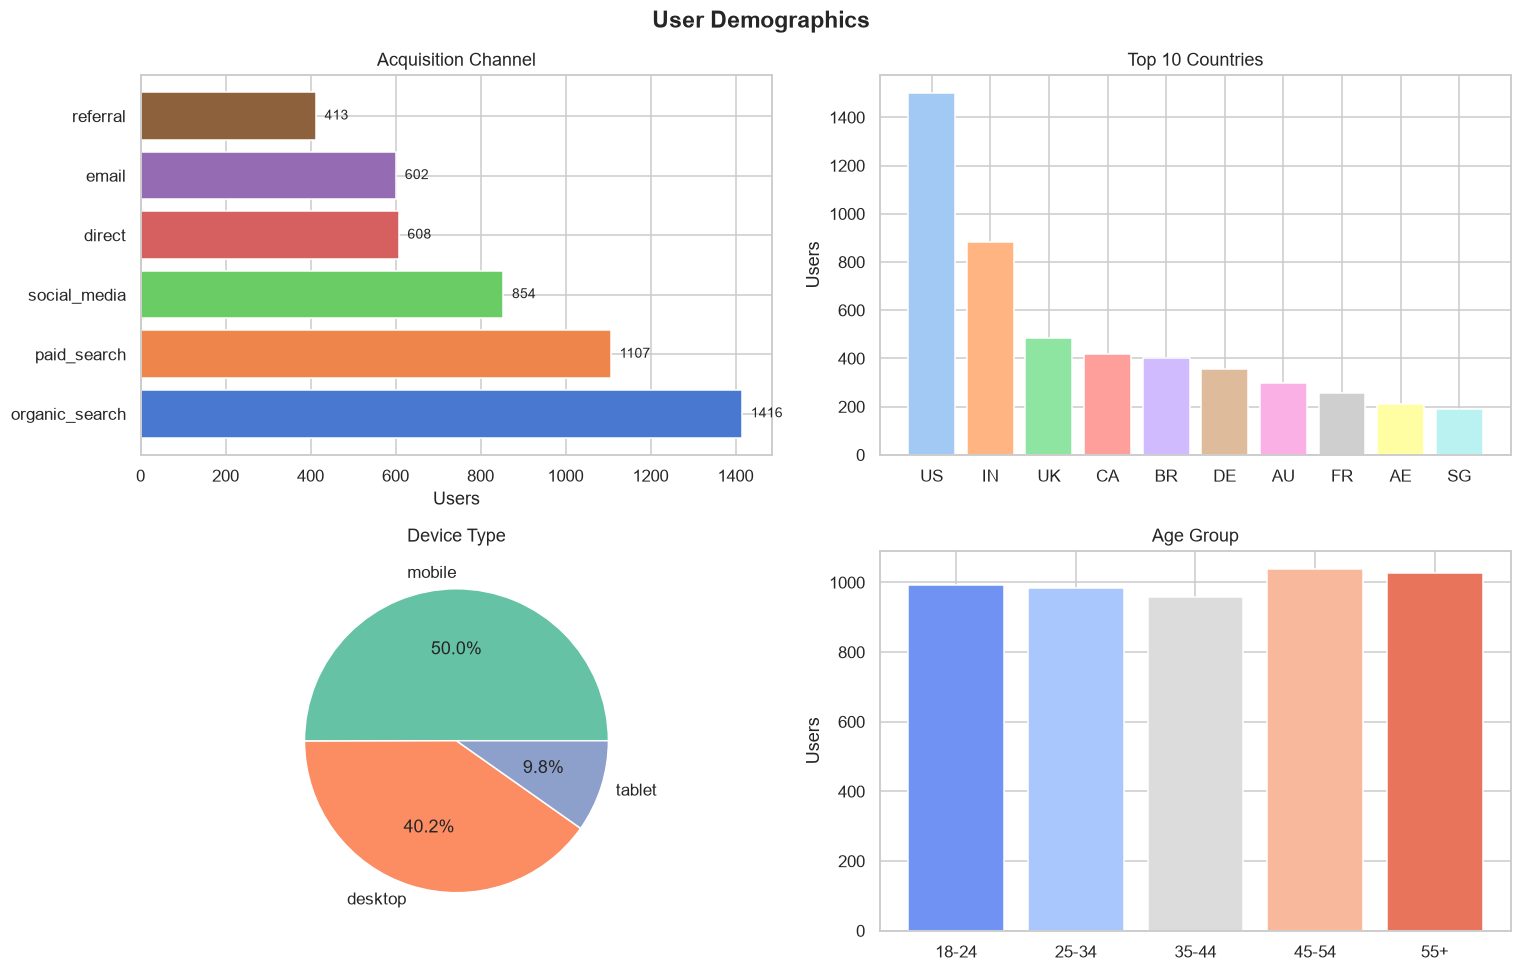

In [5]:
# Cell 5 - User Demographics
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('User Demographics', fontsize=15, fontweight='bold')

ch = df_users['acquisition_channel'].value_counts()
axes[0, 0].barh(ch.index, ch.values, color=sns.color_palette('muted', len(ch)))
axes[0, 0].set_title('Acquisition Channel')
axes[0, 0].set_xlabel('Users')
for i, v in enumerate(ch.values):
    axes[0, 0].text(v + 20, i, str(v), va='center', fontsize=9)

co = df_users['country'].value_counts().head(10)
axes[0, 1].bar(co.index, co.values, color=sns.color_palette('pastel', len(co)))
axes[0, 1].set_title('Top 10 Countries')
axes[0, 1].set_ylabel('Users')

dv = df_users['device_type'].value_counts()
axes[1, 0].pie(dv.values, labels=dv.index, autopct='%1.1f%%',
               colors=sns.color_palette('Set2', len(dv)))
axes[1, 0].set_title('Device Type')

ag = df_users['age_group'].value_counts().sort_index()
axes[1, 1].bar(ag.index, ag.values, color=sns.color_palette('coolwarm', len(ag)))
axes[1, 1].set_title('Age Group')
axes[1, 1].set_ylabel('Users')

plt.tight_layout()
plt.savefig(BASE_DIR / 'data' / 'processed' / 'eda_users.png', bbox_inches='tight')
plt.show()

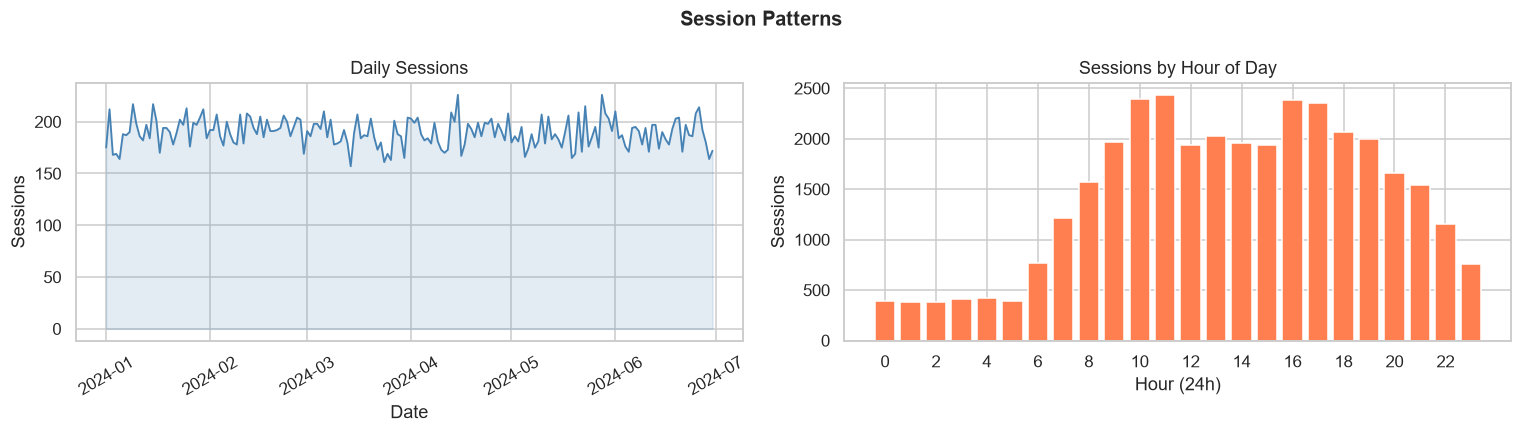

In [6]:
# Cell 6 - Session Patterns
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Session Patterns', fontsize=13, fontweight='bold')

daily = df_sessions.groupby('session_date').size().reset_index(name='sessions')
axes[0].plot(daily['session_date'], daily['sessions'], linewidth=1.2, color='steelblue')
axes[0].fill_between(daily['session_date'], daily['sessions'], alpha=0.15, color='steelblue')
axes[0].set_title('Daily Sessions')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Sessions')
axes[0].tick_params(axis='x', rotation=30)

hourly = df_sessions['session_hour'].value_counts().sort_index()
axes[1].bar(hourly.index, hourly.values, color='coral', edgecolor='white')
axes[1].set_title('Sessions by Hour of Day')
axes[1].set_xlabel('Hour (24h)')
axes[1].set_ylabel('Sessions')
axes[1].set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.savefig(BASE_DIR / 'data' / 'processed' / 'eda_sessions.png', bbox_inches='tight')
plt.show()

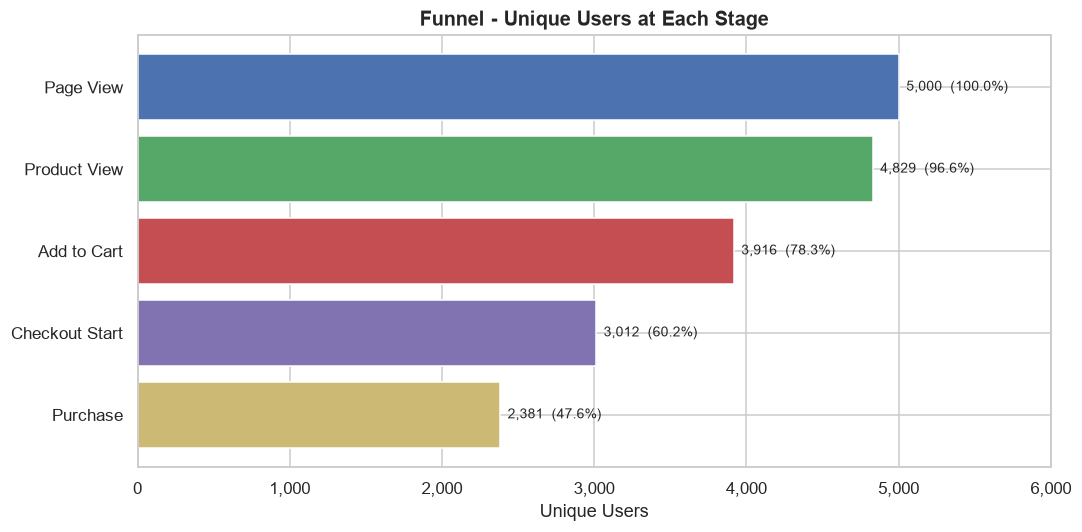

Drop-off rates:
  page_view            -> product_view          conv 96.6%  drop 3.4%
  product_view         -> add_to_cart           conv 81.1%  drop 18.9%
  add_to_cart          -> checkout_start        conv 76.9%  drop 23.1%
  checkout_start       -> purchase              conv 79.1%  drop 20.9%


In [7]:
# Cell 7 - Funnel Overview
funnel_counts = (
    df_events.groupby('event_type')['user_id'].nunique()
    .reindex(['page_view', 'product_view', 'add_to_cart', 'checkout_start', 'purchase'])
)
labels = ['Page View', 'Product View', 'Add to Cart', 'Checkout Start', 'Purchase']
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2', '#CCB974']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(labels[::-1], funnel_counts.values[::-1], color=colors[::-1], edgecolor='white')
ax.set_xlabel('Unique Users')
ax.set_title('Funnel - Unique Users at Each Stage', fontsize=13, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

top = funnel_counts.values[0]
for bar, val in zip(bars, funnel_counts.values[::-1]):
    pct = val / top * 100
    ax.text(bar.get_width() + top * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f'{val:,}  ({pct:.1f}%)', va='center', fontsize=9)
ax.set_xlim(0, top * 1.2)

plt.tight_layout()
plt.savefig(BASE_DIR / 'data' / 'processed' / 'eda_funnel.png', bbox_inches='tight')
plt.show()

print('Drop-off rates:')
vals   = funnel_counts.values
stages = ['page_view', 'product_view', 'add_to_cart', 'checkout_start', 'purchase']
for i in range(1, len(vals)):
    print(f'  {stages[i-1]:<20} -> {stages[i]:<20}  conv {vals[i]/vals[i-1]*100:.1f}%  drop {(vals[i-1]-vals[i])/vals[i-1]*100:.1f}%')

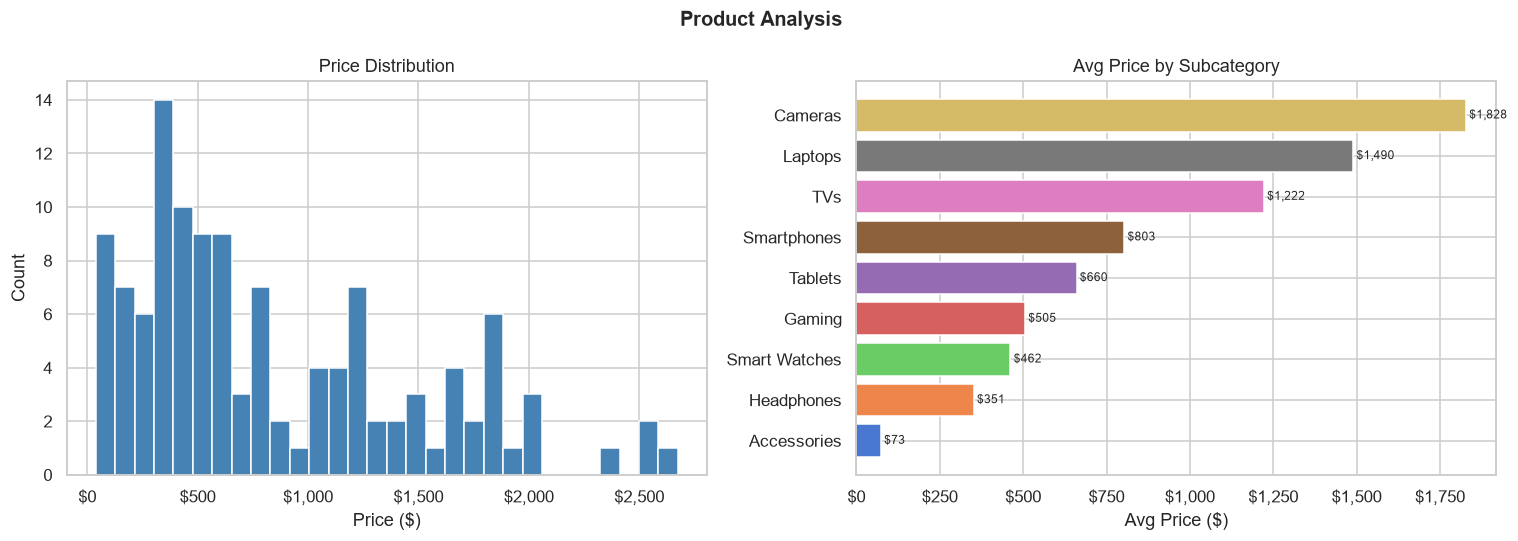

In [8]:
# Cell 8 - Product Price Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Product Analysis', fontsize=13, fontweight='bold')

axes[0].hist(df_products['price'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Price Distribution')
axes[0].set_xlabel('Price ($)')
axes[0].set_ylabel('Count')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${int(x):,}'))

subcat_price = df_products.groupby('subcategory')['price'].mean().sort_values()
axes[1].barh(subcat_price.index, subcat_price.values,
             color=sns.color_palette('muted', len(subcat_price)))
axes[1].set_title('Avg Price by Subcategory')
axes[1].set_xlabel('Avg Price ($)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${int(x):,}'))
for i, v in enumerate(subcat_price.values):
    axes[1].text(v + 10, i, f'${v:,.0f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig(BASE_DIR / 'data' / 'processed' / 'eda_products.png', bbox_inches='tight')
plt.show()

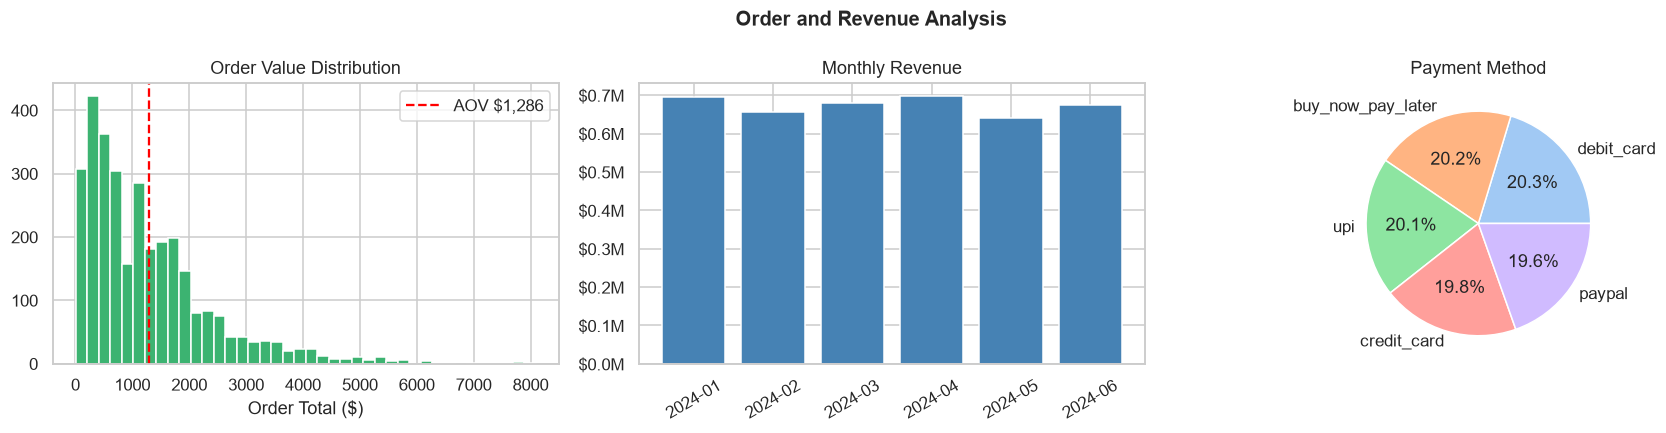

Total Revenue  : $4,040,460
Avg Order Value: $1,286.36
Total Discounts: $39,741


In [9]:
# Cell 9 - Revenue and Order Analysis
completed['month'] = pd.to_datetime(completed['order_date']).dt.strftime('%Y-%m')

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Order and Revenue Analysis', fontsize=13, fontweight='bold')

axes[0].hist(completed['total_amount'], bins=40, color='mediumseagreen', edgecolor='white')
axes[0].axvline(completed['total_amount'].mean(), color='red', linestyle='--',
                label=f'AOV ${completed["total_amount"].mean():,.0f}')
axes[0].set_title('Order Value Distribution')
axes[0].set_xlabel('Order Total ($)')
axes[0].legend()

monthly = completed.groupby('month')['total_amount'].sum()
axes[1].bar(monthly.index, monthly.values, color='steelblue', edgecolor='white')
axes[1].set_title('Monthly Revenue')
axes[1].tick_params(axis='x', rotation=30)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))

pm = df_orders['payment_method'].value_counts()
axes[2].pie(pm.values, labels=pm.index, autopct='%1.1f%%',
            colors=sns.color_palette('pastel', len(pm)))
axes[2].set_title('Payment Method')

plt.tight_layout()
plt.savefig(BASE_DIR / 'data' / 'processed' / 'eda_orders.png', bbox_inches='tight')
plt.show()

print('Total Revenue  :', f'${completed["total_amount"].sum():,.0f}')
print('Avg Order Value:', f'${completed["total_amount"].mean():,.2f}')
print('Total Discounts:', f'${completed["discount_amount"].sum():,.0f}')

In [10]:
# Cell 10 - Summary Stats and Close
orders_per_user = df_orders[df_orders['status'] == 'completed'].groupby('user_id').size()

print('=== Project Summary ===')
print('Total Users             :', f'{len(df_users):,}')
print('Total Sessions          :', f'{len(df_sessions):,}')
print('Total Events            :', f'{len(df_events):,}')
print('Completed Orders        :', f'{len(completed):,}')
print('Total Revenue           :', f'${completed["total_amount"].sum():,.0f}')
print('Avg Order Value         :', f'${completed["total_amount"].mean():,.2f}')
print('Session to Purchase Rate:', f'{len(df_orders)/len(df_sessions)*100:.1f}%')
print('Repeat Buyer Rate       :', f'{(orders_per_user >= 2).sum()/len(orders_per_user)*100:.1f}%')

conn.close()
print('DB connection closed. EDA complete.')

=== Project Summary ===
Total Users             : 5,000
Total Sessions          : 34,509
Total Events            : 79,851
Completed Orders        : 3,141
Total Revenue           : $4,040,460
Avg Order Value         : $1,286.36
Session to Purchase Rate: 10.3%
Repeat Buyer Rate       : 31.7%
DB connection closed. EDA complete.
